## Name : Tanvi Parakh
## Rollno. : C3-52
## DATE : 19-03-26
## PRACTICAL 8

In [4]:
import pandas as pd
df = pd.read_csv("IMDB Dataset.csv", engine='python', on_bad_lines='skip')

Importing Lib

In [5]:
import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from wordcloud import WordCloud

import spacy
import gradio as gr

Download Resources

In [6]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Load Dataset

In [7]:
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Handle Column Names Automatically

In [8]:
print(df.columns)

text_col = df.columns[0]
target_col = df.columns[1]

df = df[[text_col, target_col]]
df.columns = ["review", "sentiment"]

Index(['review', 'sentiment'], dtype='object')


EDA

In [9]:
df.shape

(50000, 2)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


Sentiment Distribution

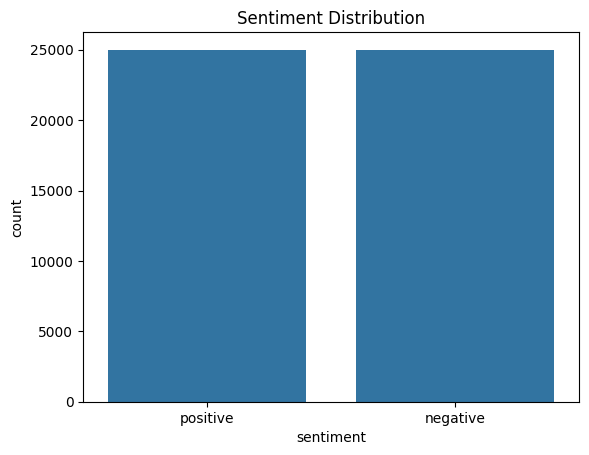

In [11]:
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

Review Length Analysis

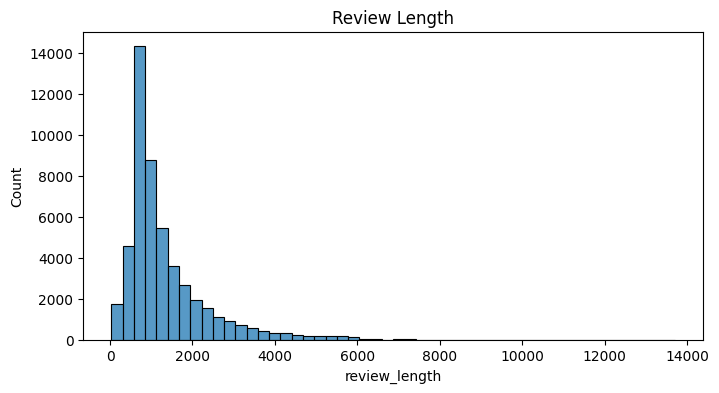

In [12]:
df["review_length"] = df["review"].apply(len)

plt.figure(figsize=(8,4))
sns.histplot(df["review_length"], bins=50)
plt.title("Review Length")
plt.show()

Missing & Duplicate Handling

In [13]:
print(df.isnull().sum())

print("Duplicates:", df.duplicated().sum())

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

review           0
sentiment        0
review_length    0
dtype: int64
Duplicates: 418


Text Preprocessing

In [14]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [15]:
stop_words = set(stopwords.words("english"))

def preprocess(text):

    text = str(text).lower()
    text = re.sub(r"<.*?>"," ",text)
    text = re.sub(r"http\S+"," ",text)
    text = re.sub(r"[^a-zA-Z]"," ",text)

    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w)>2]

    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return " ".join(tokens)

df["clean_text"] = df["review"].apply(preprocess)

WordCloud

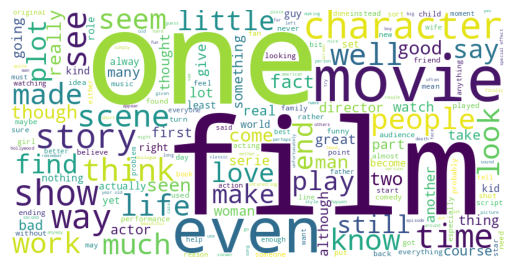

In [16]:
text = " ".join(df["clean_text"])

wordcloud = WordCloud(width=800,height=400,background_color="white").generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

Label Encoding

In [17]:
df["sentiment"] = df["sentiment"].astype(str).str.lower()

df["sentiment"] = df["sentiment"].map({
"positive":1,
"negative":0,
"pos":1,
"neg":0
})

df.dropna(inplace=True)

TF-IDF

In [18]:
vectorizer = TfidfVectorizer(
max_features=25000,
ngram_range=(1,2),
min_df=2,
max_df=0.9
)

X = vectorizer.fit_transform(df["clean_text"])
y = df["sentiment"]

Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)


TF-IDF

In [20]:
vectorizer = TfidfVectorizer(
    max_features=25000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

X = vectorizer.fit_transform(df["clean_text"])
y = df["sentiment"]

Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Train Models

In [22]:
models = {
"Naive Bayes": MultinomialNB(),
"Logistic Regression": LogisticRegression(max_iter=2000),
"Linear SVC": LinearSVC(C=1.8),
"Random Forest": RandomForestClassifier(n_estimators=400)
}

Evaluation with Full Metrics

In [24]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

results_df = pd.DataFrame(
results,
columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.880609,0.872960,0.891903,0.882330
1,Logistic Regression,0.900272,0.890674,0.913402,0.901895
2,Linear SVC,0.892004,0.890132,0.895318,0.892718
3,Random Forest,0.864273,0.859434,0.872212,0.865776


Confusion Matrix

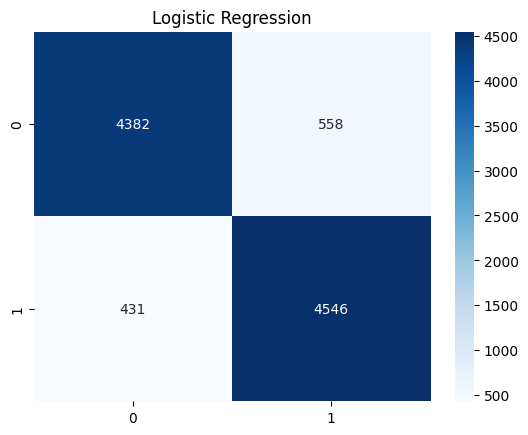

In [25]:
best_model_name = results_df.loc[results_df["Accuracy"].idxmax(),"Model"]

best_model = models[best_model_name]

best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(best_model_name)
plt.show()

Save Model

In [26]:
pickle.dump(best_model, open("sentiment_model.pkl","wb"))
pickle.dump(vectorizer, open("vectorizer.pkl","wb"))

Custom Prediction

In [27]:
def predict(text):
    clean = preprocess(text)
    vec = vectorizer.transform([clean])
    return best_model.predict(vec)[0]

predict("This movie is absolutely amazing")

np.int64(1)

Gradio GUI

In [28]:
def predict_sentiment(text):
    result = predict(text)
    return "Positive Review" if result==1 else "Negative Review"

interface = gr.Interface(
fn=predict_sentiment,
inputs="text",
outputs="text",
title="Movie Review Sentiment Analyzer"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b00cbd9e7f1edbf11c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Top Words per Class

In [29]:
feature_names = np.array(vectorizer.get_feature_names_out())

coef = best_model.coef_[0]

top_positive = feature_names[np.argsort(coef)[-20:]]
top_negative = feature_names[np.argsort(coef)[:20]]

print("Top Positive Words:", top_positive)
print("Top Negative Words:", top_negative)

Top Positive Words: ['definitely' 'well' 'love' 'enjoyable' 'superb' 'enjoyed' 'fun'
 'must see' 'hilarious' 'today' 'one best' 'loved' 'favorite' 'brilliant'
 'best' 'wonderful' 'amazing' 'perfect' 'excellent' 'great']
Top Negative Words: ['worst' 'awful' 'bad' 'boring' 'waste' 'poor' 'terrible' 'nothing'
 'horrible' 'dull' 'worse' 'poorly' 'fails' 'annoying' 'supposed' 'stupid'
 'lame' 'unfortunately' 'disappointment' 'disappointing']
